# Red Veterinaria Mexikans
## Análisis Exploratorio de Datos

Después de generar el dataset veterinario sintético en el notebook anterior, el siguiente paso es realizar un análisis exploratorio de datos (EDA).

El objetivo de este notebook es entender cómo opera la red de clínicas veterinarias Mexikans examinando:

- distribución geográfica de las clínicas
- patrones de demanda a lo largo del tiempo
- utilización de servicios veterinarios
- comportamiento de los clientes
- desempeño de las clínicas
- eficiencia operativa

El análisis exploratorio ayuda a identificar patrones, relaciones y posibles anomalías en los datos antes de construir modelos predictivos.

Los insights generados en este notebook guiarán las siguientes etapas del proyecto:

- ingeniería de características
- segmentación de clínicas
- pronóstico de demanda
- explicabilidad de modelos

El análisis se realizará tanto a **nivel de red** como a **nivel de clínica**.

In [1]:
"""
Configuración del Entorno
"""

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

NOTEBOOK_ID = "02_exploratory_analysis"

FIGURES_DIR = Path("../figures")

def save_plot(name):

    folder = FIGURES_DIR / NOTEBOOK_ID
    folder.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        folder / f"{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

print("Entorno listo.")

Entorno listo.


## Cargar Datasets Generados

In [2]:
cities_df = pd.read_csv("../data/cities.csv")
clinics_df = pd.read_csv("../data/clinics.csv")
services_df = pd.read_csv("../data/services.csv")
pets_df = pd.read_csv("../data/pets.csv")
calendar_df = pd.read_csv("../data/calendar.csv")

visits_df = pd.read_csv("../data/visits.csv", parse_dates=["visit_date"])
daily_metrics_df = pd.read_csv("../data/daily_metrics.csv", parse_dates=["visit_date"])

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


## Visión General del Dataset

Antes de analizar los patrones en los datos, primero reviso el tamaño y la estructura de los datasets.

In [3]:
print("Ciudades:", len(cities_df))
print("Clínicas:", len(clinics_df))
print("Mascotas:", len(pets_df))
print("Visitas:", len(visits_df))
print("Registros operativos:", len(daily_metrics_df))

Ciudades: 14
Clínicas: 50
Mascotas: 25000
Visitas: 753441
Registros operativos: 90917


## Estructura de la Red

Comienzo examinando cómo están distribuidas las clínicas veterinarias entre las distintas ciudades.

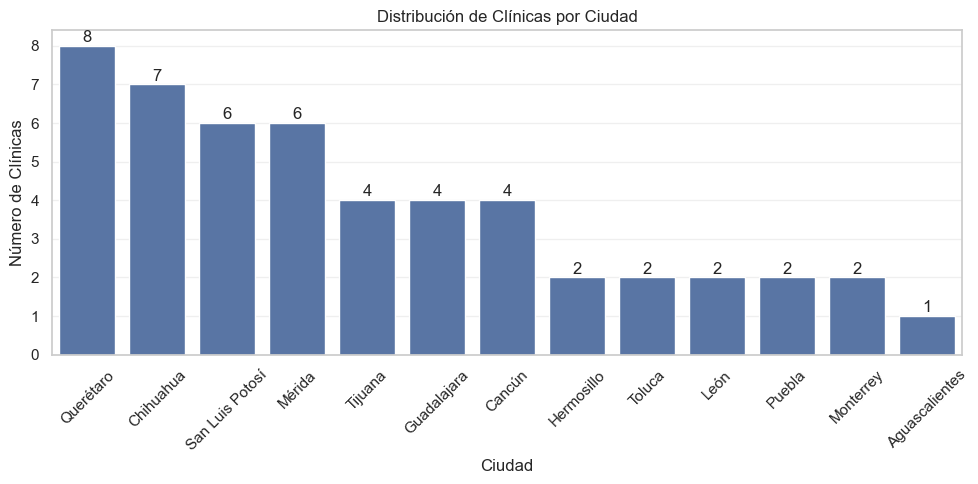

In [4]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=clinics_df,
    x="city",
    order=clinics_df["city"].value_counts().index
)

plt.title("Distribución de Clínicas por Ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Número de Clínicas")

plt.xticks(rotation=45)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.1,
        int(p.get_height()),
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

save_plot("clinics_by_city")

plt.tight_layout()

plt.show()

## Demanda Geográfica

A continuación examino cómo se distribuyen las visitas veterinarias entre las distintas ciudades.

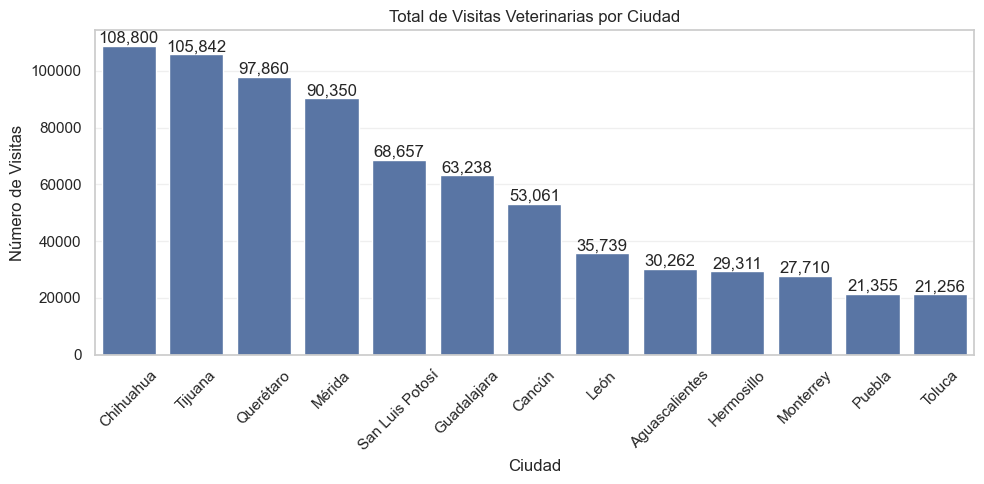

In [5]:
visits_city = visits_df.merge(
    clinics_df[["clinic_id","city"]],
    on="clinic_id"
)

city_visits = (
    visits_city
    .groupby("city")["visit_id"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=city_visits.index,
    y=city_visits.values
)

plt.title("Total de Visitas Veterinarias por Ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Número de Visitas")

plt.xticks(rotation=45)

for i, v in enumerate(city_visits.values):
    ax.text(
        i,
        v + max(city_visits.values)*0.01,
        f"{v:,}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

save_plot("visits_by_city")

plt.tight_layout()

plt.show()

## Patrones Temporales de Demanda

La demanda veterinaria evoluciona a lo largo del tiempo debido a la estacionalidad, las campañas de vacunación y el crecimiento en la tenencia de mascotas.

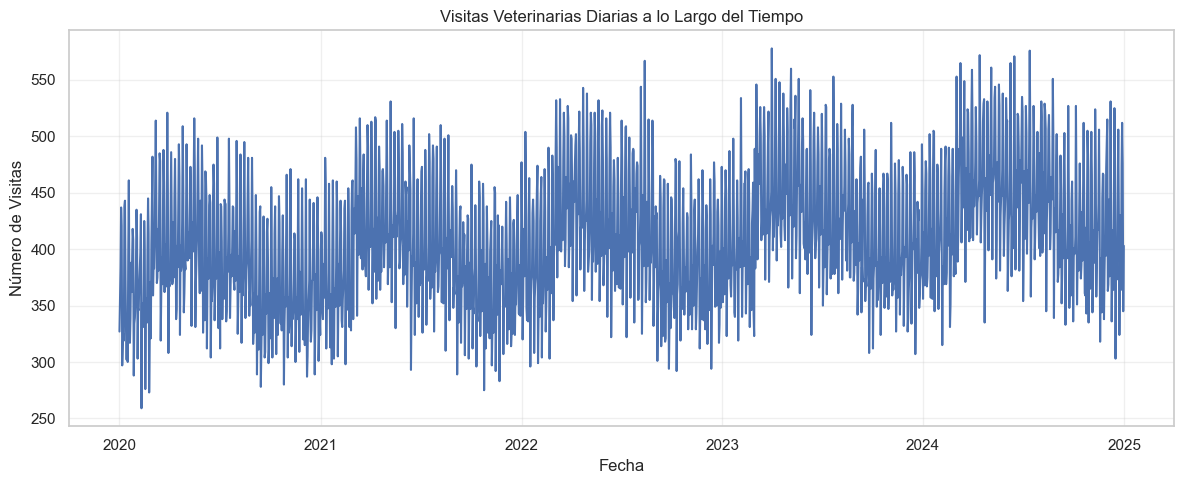

In [6]:
daily_visits = (
    visits_df
    .groupby("visit_date")["visit_id"]
    .count()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=daily_visits.index,
    y=daily_visits.values
)

plt.title("Visitas Veterinarias Diarias a lo Largo del Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Número de Visitas")

plt.grid(alpha=0.3)

save_plot("daily_visits_timeseries")

plt.tight_layout()

plt.show()

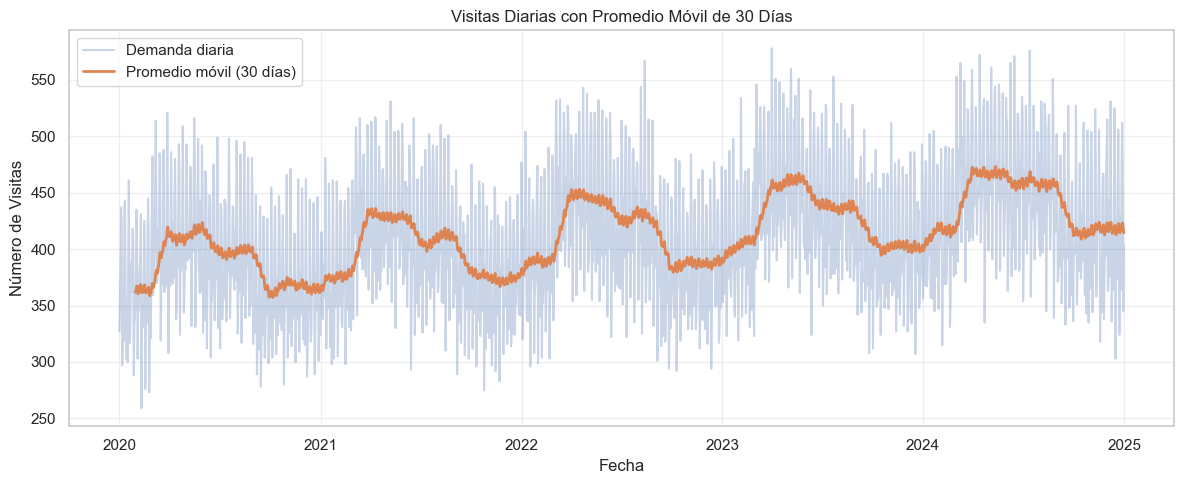

In [7]:
rolling = daily_visits.rolling(30).mean()

plt.figure(figsize=(12,5))

plt.plot(
    daily_visits.index,
    daily_visits.values,
    alpha=0.3,
    label="Demanda diaria"
)

plt.plot(
    rolling.index,
    rolling.values,
    label="Promedio móvil (30 días)",
    linewidth=2
)

plt.title("Visitas Diarias con Promedio Móvil de 30 Días")
plt.xlabel("Fecha")
plt.ylabel("Número de Visitas")

plt.legend()

plt.grid(alpha=0.3)

save_plot("rolling_30d_demand")

plt.tight_layout()

plt.show()

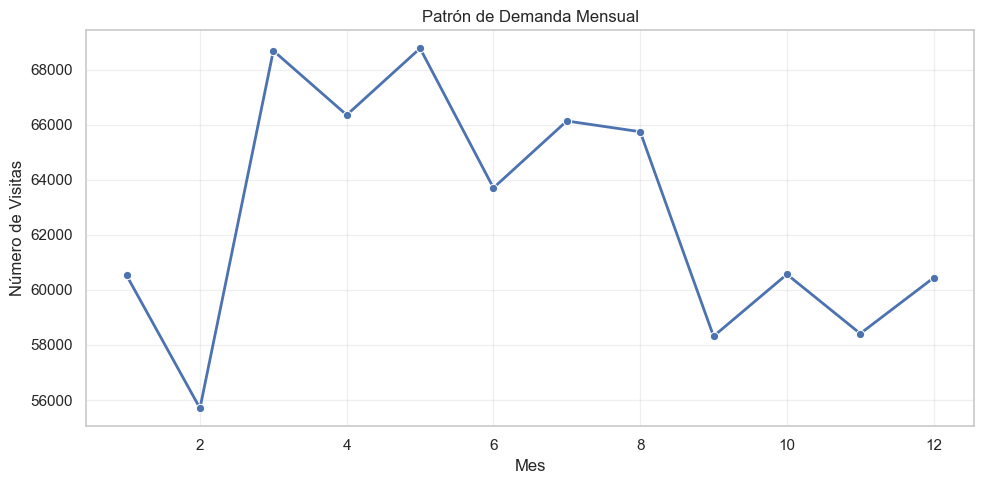

In [8]:
visits_df["month"] = visits_df["visit_date"].dt.month

monthly_visits = (
    visits_df
    .groupby("month")["visit_id"]
    .count()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_visits.index,
    y=monthly_visits.values,
    marker="o",
    linewidth=2
)

plt.title("Patrón de Demanda Mensual")
plt.xlabel("Mes")
plt.ylabel("Número de Visitas")

plt.grid(alpha=0.3)

save_plot("monthly_demand_pattern")

plt.tight_layout()

plt.show()

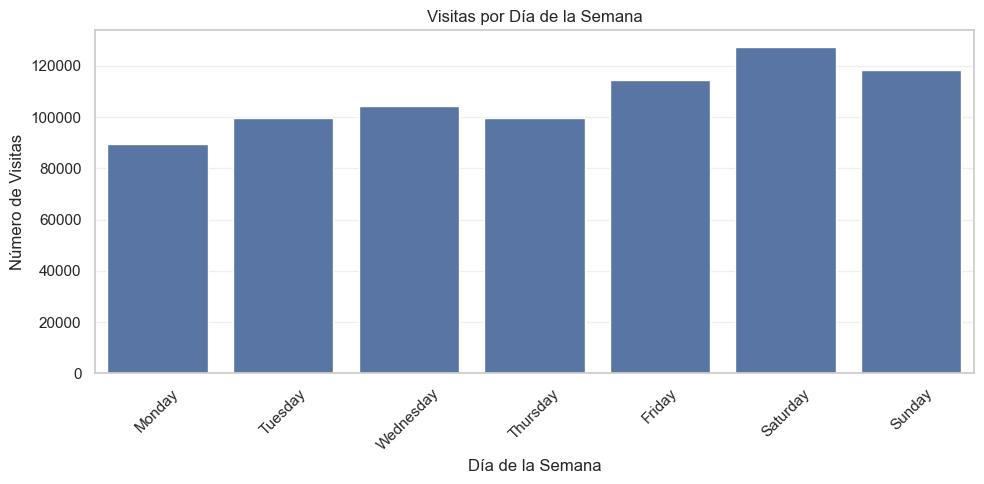

In [9]:
visits_df["weekday"] = visits_df["visit_date"].dt.day_name()

order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_visits = (
    visits_df
    .groupby("weekday")["visit_id"]
    .count()
    .reindex(order)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_visits.index,
    y=weekday_visits.values
)

plt.title("Visitas por Día de la Semana")
plt.xlabel("Día de la Semana")
plt.ylabel("Número de Visitas")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

save_plot("weekday_demand_pattern")

plt.tight_layout()

plt.show()

## Análisis de Servicios Veterinarios

Las clínicas veterinarias ofrecen una amplia gama de servicios médicos que varían en complejidad, duración e impacto económico.

Comprender cómo se distribuyen estos servicios a lo largo de la red ayuda a revelar aspectos importantes de las operaciones de las clínicas, incluyendo:

- qué procedimientos se realizan con mayor frecuencia
- qué servicios contribuyen más a los ingresos de las clínicas
- cómo se distribuye la carga operativa entre los diferentes tipos de atención

Analizar la mezcla de servicios también proporciona información sobre el equilibrio entre la atención preventiva de rutina y los procedimientos médicos más complejos.

En esta sección examino la distribución de los servicios veterinarios en toda la red Mexikans para entender mejor cómo está estructurada la actividad clínica.

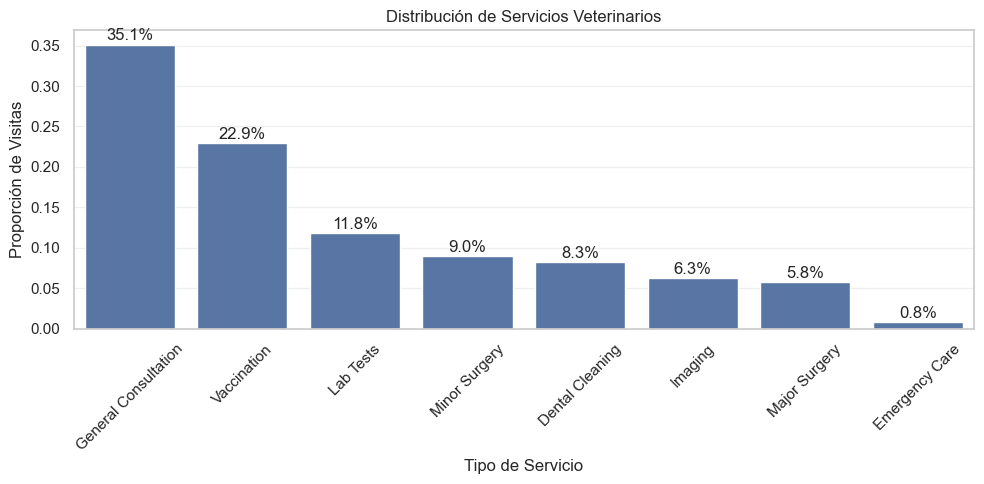

In [10]:
service_mix = visits_df["service_type"].value_counts(normalize=True)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=service_mix.index,
    y=service_mix.values
)

plt.title("Distribución de Servicios Veterinarios")
plt.xlabel("Tipo de Servicio")
plt.ylabel("Proporción de Visitas")

plt.xticks(rotation=45)

for i, v in enumerate(service_mix.values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("service_mix_distribution")

plt.tight_layout()

plt.show()

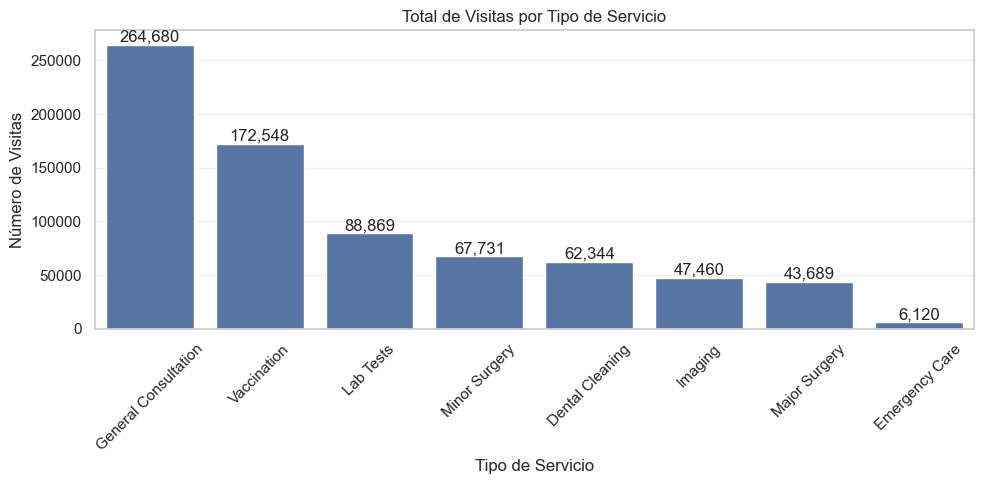

In [11]:
service_visits = visits_df["service_type"].value_counts()

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=service_visits.index,
    y=service_visits.values
)

plt.title("Total de Visitas por Tipo de Servicio")
plt.xlabel("Tipo de Servicio")
plt.ylabel("Número de Visitas")

plt.xticks(rotation=45)

for i, v in enumerate(service_visits.values):
    ax.text(i, v + max(service_visits.values)*0.01, f"{v:,}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("service_visits_total")

plt.tight_layout()

plt.show()

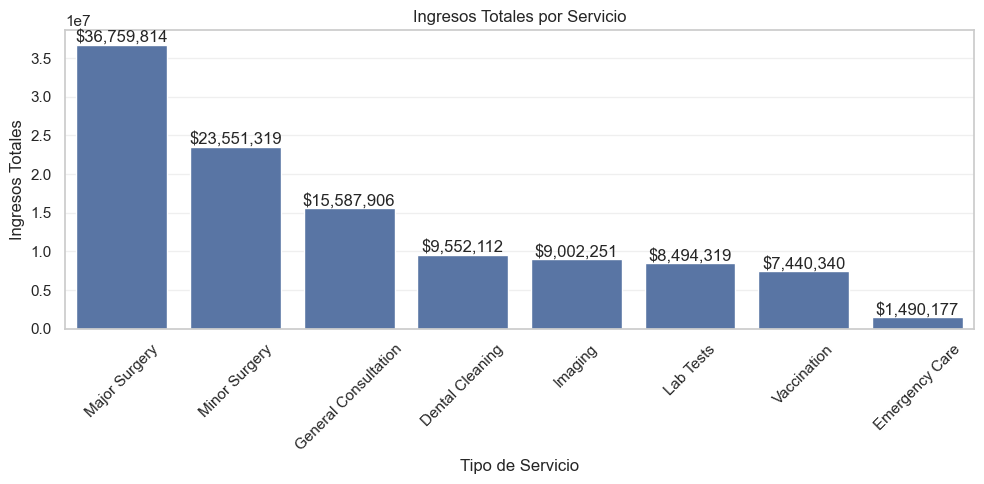

In [12]:
revenue_service = (
    visits_df
    .groupby("service_type")["total_visit_cost"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=revenue_service.index,
    y=revenue_service.values
)

plt.title("Ingresos Totales por Servicio")
plt.xlabel("Tipo de Servicio")
plt.ylabel("Ingresos Totales")

plt.xticks(rotation=45)

for i, v in enumerate(revenue_service.values):
    ax.text(i, v + max(revenue_service.values)*0.01, f"${v:,.0f}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("revenue_by_service")

plt.tight_layout()

plt.show()

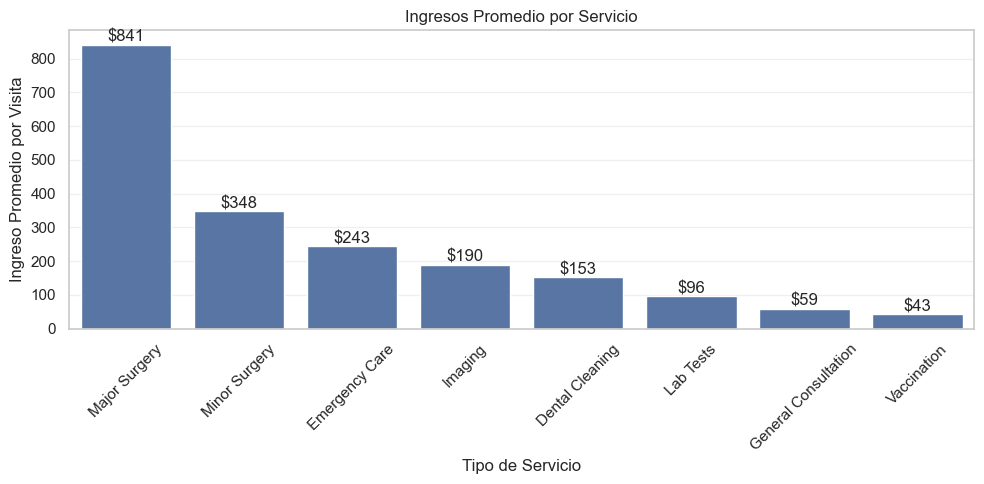

In [13]:
avg_revenue_service = (
    visits_df
    .groupby("service_type")["total_visit_cost"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=avg_revenue_service.index,
    y=avg_revenue_service.values
)

plt.title("Ingresos Promedio por Servicio")
plt.xlabel("Tipo de Servicio")
plt.ylabel("Ingreso Promedio por Visita")

plt.xticks(rotation=45)

for i, v in enumerate(avg_revenue_service.values):
    ax.text(i, v + max(avg_revenue_service.values)*0.01, f"${v:,.0f}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("avg_revenue_by_service")

plt.tight_layout()

plt.show()

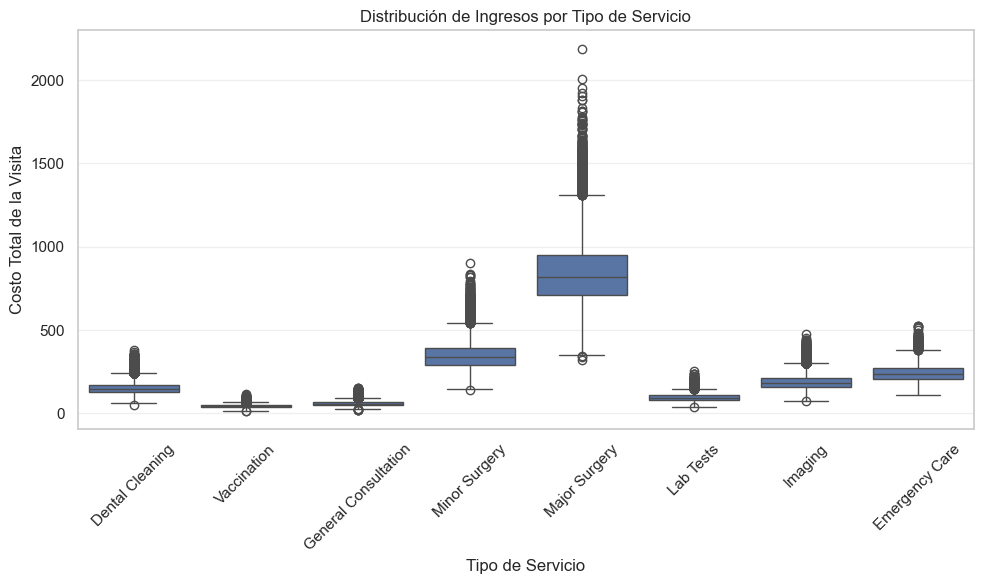

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=visits_df,
    x="service_type",
    y="total_visit_cost"
)

plt.title("Distribución de Ingresos por Tipo de Servicio")
plt.xlabel("Tipo de Servicio")
plt.ylabel("Costo Total de la Visita")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

save_plot("revenue_distribution_by_service")

plt.tight_layout()

plt.show()

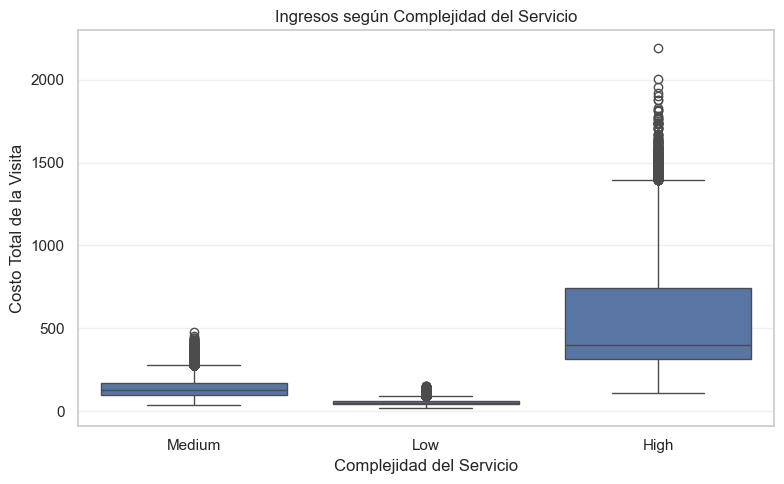

In [15]:
service_complexity = visits_df.merge(
    services_df[["service_type","complexity"]],
    on="service_type"
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=service_complexity,
    x="complexity",
    y="total_visit_cost"
)

plt.title("Ingresos según Complejidad del Servicio")
plt.xlabel("Complejidad del Servicio")
plt.ylabel("Costo Total de la Visita")

plt.grid(axis="y", alpha=0.3)

save_plot("revenue_by_service_complexity")

plt.tight_layout()

plt.show()

### Insight

Los servicios rutinarios como las consultas generales y las vacunaciones representan la mayoría de las visitas veterinarias en toda la red Mexikans. Estos servicios constituyen el núcleo de la atención veterinaria preventiva y generan una gran parte del flujo de pacientes hacia las clínicas.

En contraste, los procedimientos más complejos como las cirugías y los estudios de imagen ocurren con menor frecuencia, pero generan ingresos significativamente mayores por visita.

Esto revela una dinámica operativa importante dentro de la red: los servicios rutinarios de alto volumen sostienen la actividad de las clínicas y la relación con los clientes, mientras que los procedimientos especializados contribuyen de manera desproporcionada a la generación de ingresos.

## Análisis del Comportamiento de los Clientes

Comprender cómo interactúan los clientes con las clínicas veterinarias es fundamental para identificar patrones en la utilización de servicios de salud y en la relación a largo plazo con la atención veterinaria.

En el contexto de la red Mexikans, el comportamiento de los clientes puede analizarse a través de la interacción entre los dueños de mascotas, sus animales y las clínicas que visitan.

En esta sección examino varios aspectos del comportamiento de los clientes, incluyendo:

- con qué frecuencia las mascotas visitan clínicas veterinarias
- diferencias en la demanda de atención médica entre tipos de mascotas
- la contribución de ingresos asociada a cada categoría de mascota
- la distribución de visitas dentro de la población de mascotas

Analizar estos patrones proporciona información sobre el ciclo de vida de los pacientes veterinarios y ayuda a identificar oportunidades para mejorar los programas de atención preventiva, las estrategias de retención de clientes y las ofertas de servicios dirigidas.

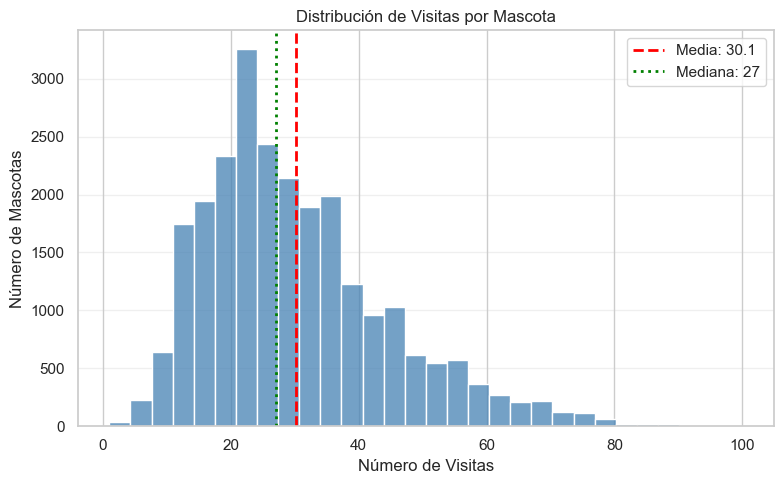

In [16]:
"""
Distribución de Visitas por Mascota
"""

visits_per_pet = visits_df.groupby("pet_id")["visit_id"].count()

plt.figure(figsize=(8,5))

sns.histplot(
    visits_per_pet,
    bins=30,
    color="steelblue"
)

mean_visits = visits_per_pet.mean()
median_visits = visits_per_pet.median()

plt.axvline(
    mean_visits,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: {mean_visits:.1f}"
)

plt.axvline(
    median_visits,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {median_visits:.0f}"
)

plt.title("Distribución de Visitas por Mascota")
plt.xlabel("Número de Visitas")
plt.ylabel("Número de Mascotas")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("visits_per_pet_distribution")

plt.tight_layout()

plt.show()

In [17]:
"""
Promedio de Visitas por Mascota
"""

avg_visits_pet = visits_per_pet.mean()

print("Promedio de visitas por mascota:", round(avg_visits_pet,2))

Promedio de visitas por mascota: 30.14


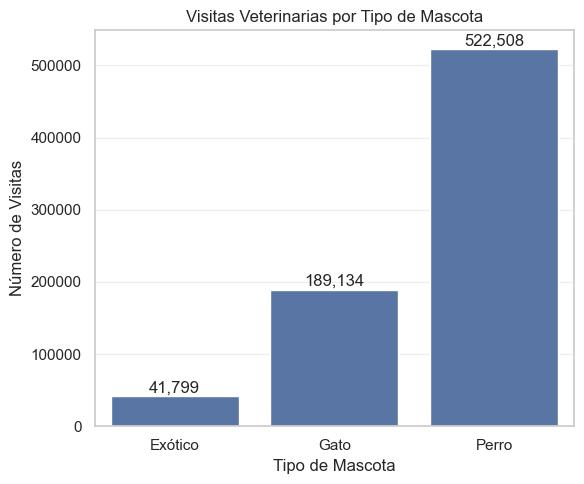

In [18]:
"""
Demanda por Tipo de Mascota
"""

pet_demand = (
    visits_df
    .groupby("pet_type")["visit_id"]
    .count()
)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=pet_demand.index,
    y=pet_demand.values
)

plt.title("Visitas Veterinarias por Tipo de Mascota")
plt.xlabel("Tipo de Mascota")
plt.ylabel("Número de Visitas")

for i, v in enumerate(pet_demand.values):
    ax.text(i, v + max(pet_demand.values)*0.01, f"{v:,}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("demand_by_pet_type")

plt.tight_layout()

plt.show()

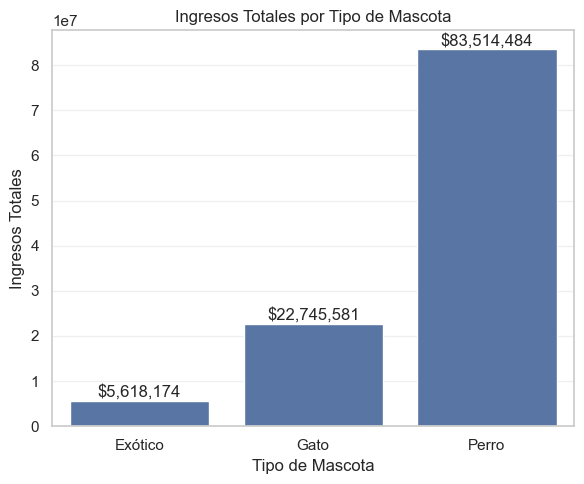

In [19]:
"""
Ingresos por Tipo de Mascota
"""

revenue_pet = (
    visits_df
    .groupby("pet_type")["total_visit_cost"]
    .sum()
)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=revenue_pet.index,
    y=revenue_pet.values
)

plt.title("Ingresos Totales por Tipo de Mascota")
plt.xlabel("Tipo de Mascota")
plt.ylabel("Ingresos Totales")

for i, v in enumerate(revenue_pet.values):
    ax.text(i, v + max(revenue_pet.values)*0.01, f"${v:,.0f}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("revenue_by_pet_type")

plt.tight_layout()

plt.show()

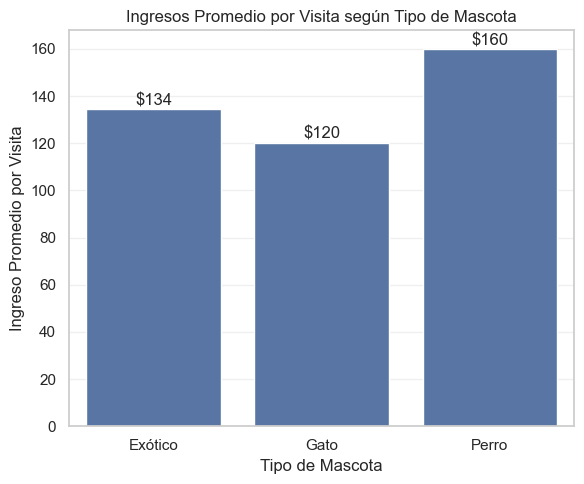

In [20]:
"""
Ingresos Promedio por Visita según Tipo de Mascota
"""

avg_revenue_pet = (
    visits_df
    .groupby("pet_type")["total_visit_cost"]
    .mean()
)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=avg_revenue_pet.index,
    y=avg_revenue_pet.values
)

plt.title("Ingresos Promedio por Visita según Tipo de Mascota")
plt.xlabel("Tipo de Mascota")
plt.ylabel("Ingreso Promedio por Visita")

for i, v in enumerate(avg_revenue_pet.values):
    ax.text(i, v + max(avg_revenue_pet.values)*0.01, f"${v:,.0f}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("avg_revenue_by_pet_type")

plt.tight_layout()

plt.show()

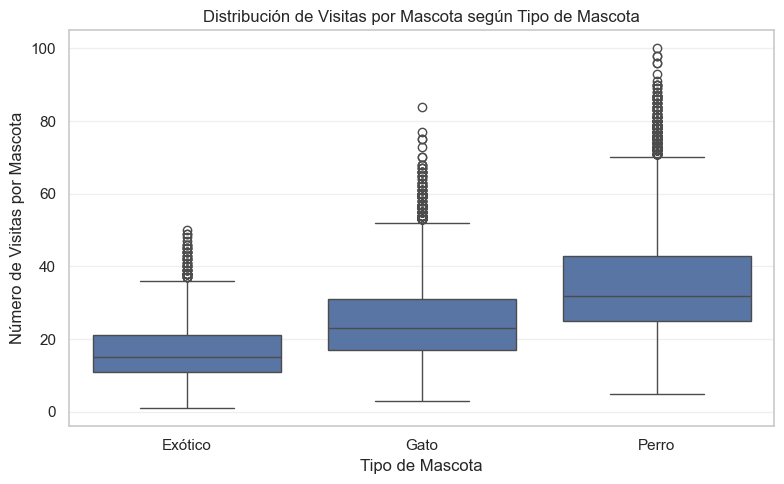

In [21]:
"""
Visitas por Mascota según Tipo de Mascota
"""

visits_pet_type = (
    visits_df
    .groupby(["pet_type","pet_id"])["visit_id"]
    .count()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=visits_pet_type,
    x="pet_type",
    y="visit_id"
)

plt.title("Distribución de Visitas por Mascota según Tipo de Mascota")
plt.xlabel("Tipo de Mascota")
plt.ylabel("Número de Visitas por Mascota")

plt.grid(axis="y", alpha=0.3)

save_plot("visits_per_pet_by_type")

plt.tight_layout()

plt.show()

### Insight

El análisis del comportamiento de los clientes muestra que los perros representan la mayor proporción de visitas veterinarias y de ingresos totales en toda la red Mexikans. Esto refleja tanto su mayor presencia en la población de mascotas como su mayor utilización de servicios de salud.

Los gatos representan una porción menor pero aún significativa de la demanda veterinaria, mientras que los animales exóticos constituyen una fracción mucho más pequeña de las visitas debido a su menor tamaño poblacional y a sus necesidades de atención más especializadas.

La distribución de visitas por mascota indica patrones recurrentes de atención veterinaria, donde la mayoría de las mascotas visitan las clínicas algunas veces al año para chequeos de rutina, vacunaciones y tratamientos médicos ocasionales.

Este patrón destaca el papel central de la atención preventiva para sostener la actividad de las clínicas y mantener relaciones a largo plazo entre los dueños de mascotas y los proveedores veterinarios.

## Análisis del Desempeño de las Clínicas

Evaluar el desempeño de las clínicas individuales es fundamental para gestionar de manera eficiente una red de clínicas veterinarias. Las diferencias en la demanda, la capacidad y la eficiencia operativa pueden generar variaciones significativas en el rendimiento de las clínicas dentro de la red.

En esta sección analizo el desempeño a nivel de clínica en toda la red veterinaria Mexikans con el objetivo de entender cómo distintas clínicas contribuyen a la actividad y a los ingresos totales.

Las preguntas clave abordadas en este análisis incluyen:

- ¿Qué clínicas generan los mayores ingresos?
- ¿Qué clínicas reciben el mayor volumen de pacientes?
- ¿Existen clínicas que operan por debajo de su capacidad potencial?
- ¿Existe una relación entre la utilización de la clínica y la generación de ingresos?

Comprender estos patrones ayuda a identificar clínicas de alto desempeño, detectar ubicaciones subutilizadas y destacar oportunidades para mejorar la eficiencia operativa en toda la red.

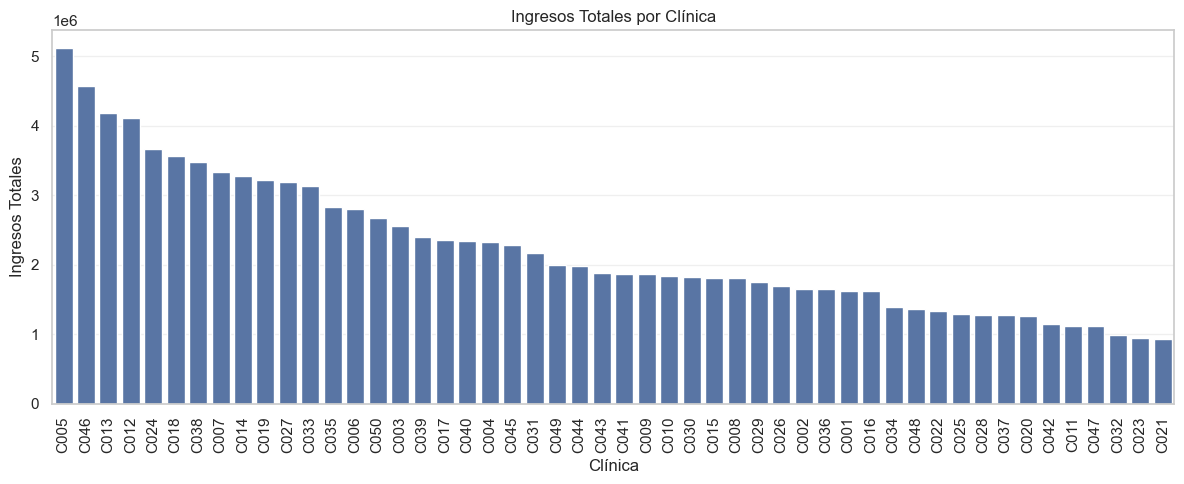

In [22]:
"""
Ingresos Totales por Clínica
"""

revenue_clinic = (
    visits_df
    .groupby("clinic_id")["total_visit_cost"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=revenue_clinic.index,
    y=revenue_clinic.values
)

plt.title("Ingresos Totales por Clínica")
plt.xlabel("Clínica")
plt.ylabel("Ingresos Totales")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)

save_plot("revenue_per_clinic")

plt.tight_layout()

plt.show()

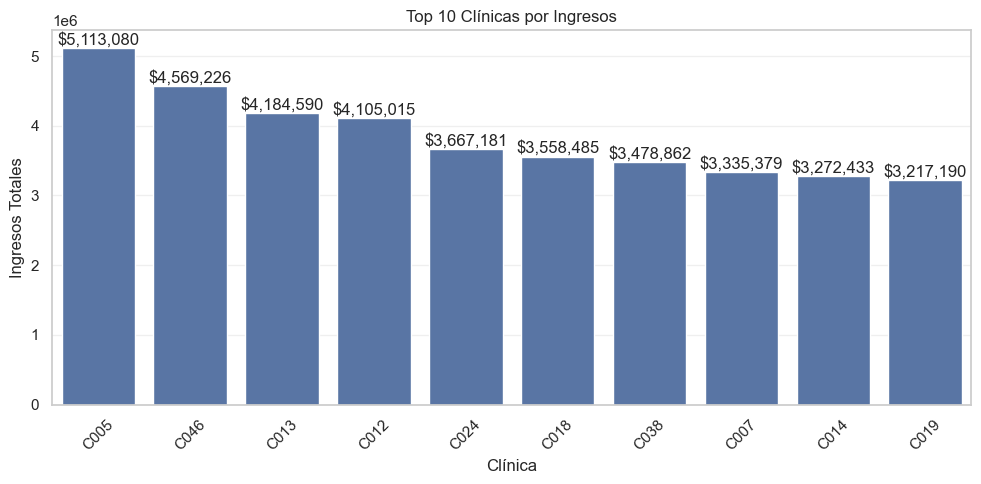

In [23]:
"""
Top 10 Clínicas por Ingresos
"""

top_clinics = revenue_clinic.head(10)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_clinics.index,
    y=top_clinics.values
)

plt.title("Top 10 Clínicas por Ingresos")
plt.xlabel("Clínica")
plt.ylabel("Ingresos Totales")

plt.xticks(rotation=45)

for i, v in enumerate(top_clinics.values):
    ax.text(i, v + max(top_clinics.values)*0.01, f"${v:,.0f}", ha="center")

plt.grid(axis="y", alpha=0.3)

save_plot("top_10_clinics_by_revenue")

plt.tight_layout()

plt.show()

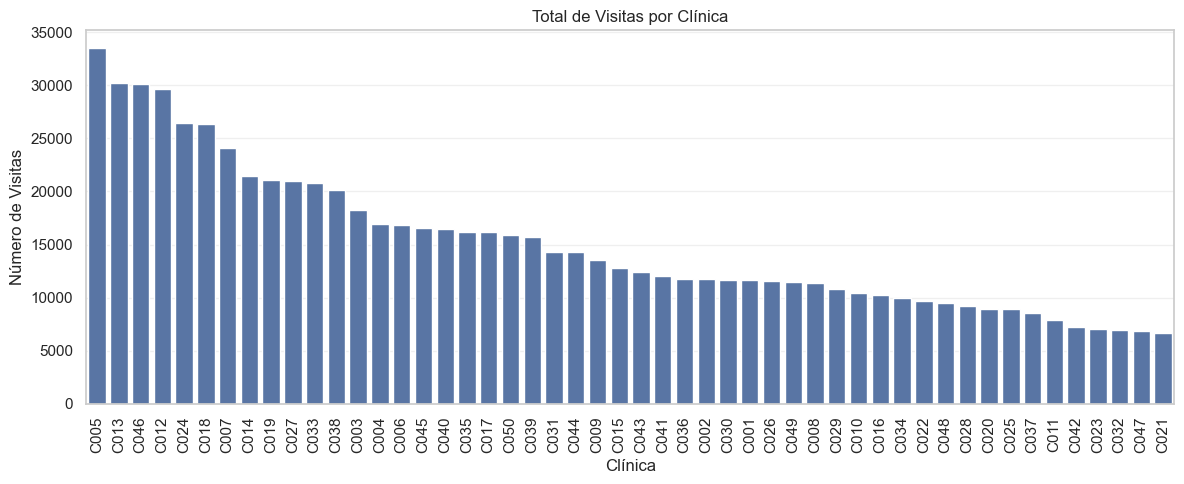

In [24]:
"""
Total de Visitas por Clínica
"""

visits_clinic = (
    visits_df
    .groupby("clinic_id")["visit_id"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=visits_clinic.index,
    y=visits_clinic.values
)

plt.title("Total de Visitas por Clínica")
plt.xlabel("Clínica")
plt.ylabel("Número de Visitas")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)

save_plot("visits_per_clinic")

plt.tight_layout()

plt.show()

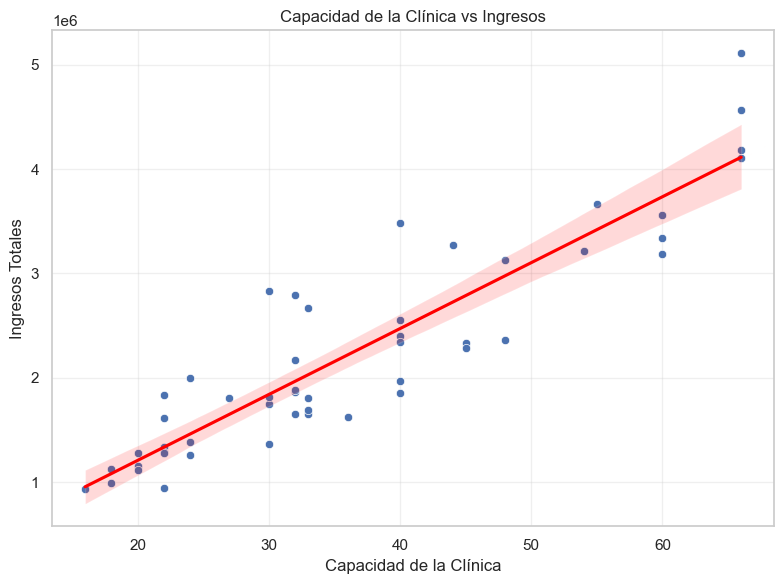

In [25]:
clinic_capacity = visits_df.merge(
    clinics_df[["clinic_id","clinic_capacity"]],
    on="clinic_id"
)

clinic_capacity_perf = (
    clinic_capacity
    .groupby("clinic_id")
    .agg(
        revenue=("total_visit_cost","sum"),
        capacity=("clinic_capacity","mean")
    )
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clinic_capacity_perf,
    x="capacity",
    y="revenue"
)

sns.regplot(
    data=clinic_capacity_perf,
    x="capacity",
    y="revenue",
    scatter=False,
    color="red"
)

plt.title("Capacidad de la Clínica vs Ingresos")
plt.xlabel("Capacidad de la Clínica")
plt.ylabel("Ingresos Totales")

plt.grid(alpha=0.3)

save_plot("capacity_vs_revenue")

plt.tight_layout()

plt.show()

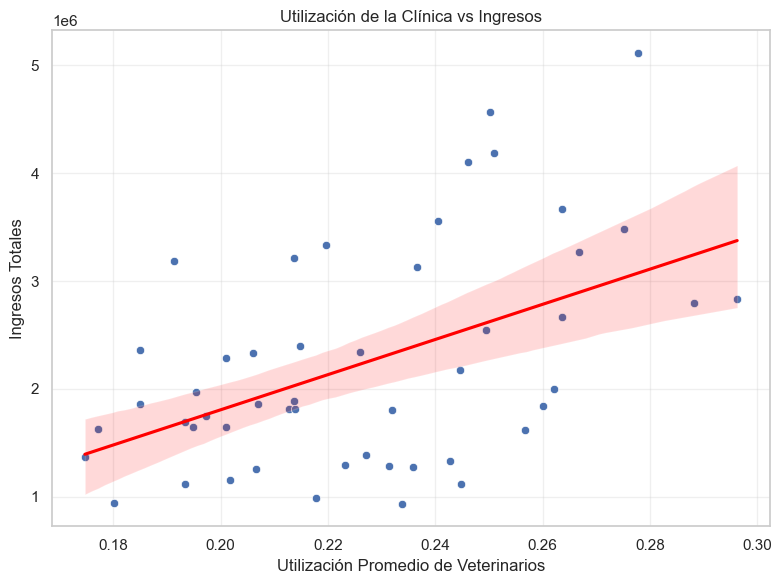

In [26]:
clinic_perf = (
    daily_metrics_df
    .groupby("clinic_id")
    .agg(
        avg_utilization=("vet_utilization_rate","mean"),
        total_revenue=("daily_revenue","sum")
    )
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clinic_perf,
    x="avg_utilization",
    y="total_revenue"
)

sns.regplot(
    data=clinic_perf,
    x="avg_utilization",
    y="total_revenue",
    scatter=False,
    color="red"
)

plt.title("Utilización de la Clínica vs Ingresos")
plt.xlabel("Utilización Promedio de Veterinarios")
plt.ylabel("Ingresos Totales")

plt.grid(alpha=0.3)

save_plot("utilization_vs_revenue")

plt.tight_layout()

plt.show()

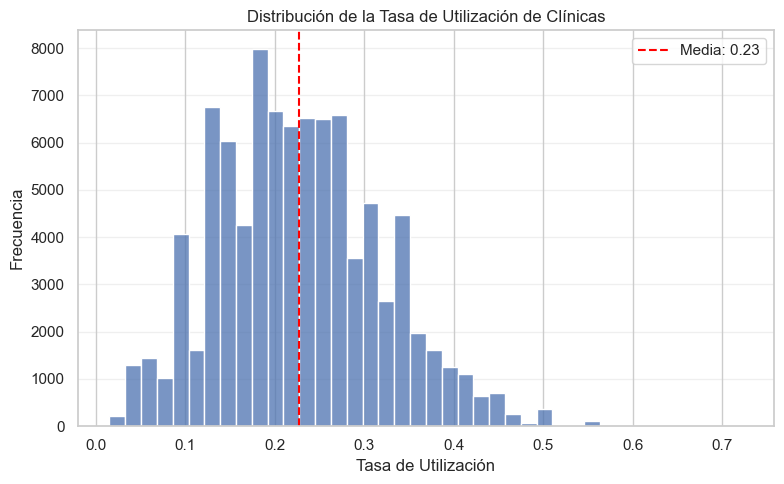

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    daily_metrics_df["vet_utilization_rate"],
    bins=40
)

mean_util = daily_metrics_df["vet_utilization_rate"].mean()

plt.axvline(
    mean_util,
    color="red",
    linestyle="--",
    label=f"Media: {mean_util:.2f}"
)

plt.title("Distribución de la Tasa de Utilización de Clínicas")
plt.xlabel("Tasa de Utilización")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("clinic_utilization_distribution")

plt.tight_layout()

plt.show()

### Insight

El desempeño de las clínicas varía significativamente en toda la red Mexikans.

Algunas clínicas generan ingresos y volúmenes de visitas considerablemente más altos que otras. Estas diferencias pueden estar impulsadas por factores como la ubicación, la capacidad de la clínica y las condiciones de demanda locales.

El análisis también revela que los niveles de utilización de las clínicas difieren a lo largo de la red. Mientras que algunas clínicas operan cerca de su capacidad máxima, otras parecen tener margen para absorber una mayor demanda.

Identificar estas diferencias de desempeño puede ayudar a orientar decisiones estratégicas como la expansión de clínicas, ajustes en el personal y iniciativas de marketing dirigidas.

## Análisis de Eficiencia Operativa

Además del desempeño financiero, las redes de clínicas veterinarias deben monitorear de cerca los indicadores operativos que influyen tanto en la eficiencia del servicio como en la experiencia general del cliente.

Las métricas operativas proporcionan información sobre qué tan eficazmente las clínicas gestionan el flujo de pacientes, asignan recursos y manejan las variaciones en la demanda.

Dos indicadores operativos clave analizados en esta sección son:

### Tiempo Promedio de Espera

El tiempo promedio de espera refleja qué tan eficientemente las clínicas gestionan la demanda de pacientes y la programación de citas. Tiempos de espera más largos pueden indicar cuellos de botella operativos, alta presión de demanda o capacidad disponible limitada.

### Utilización y Presión Operativa

A medida que las clínicas se acercan a su capacidad operativa máxima, aumenta la presión sobre el personal y los recursos. Niveles más altos de utilización pueden generar tiempos de espera más largos y potencialmente afectar la calidad del servicio si la demanda supera consistentemente la capacidad disponible.

En esta sección analizo:

- la distribución de los tiempos de espera en las clínicas de toda la red
- la relación entre la utilización de las clínicas y los tiempos de espera
- las correlaciones entre indicadores clave de desempeño operativo

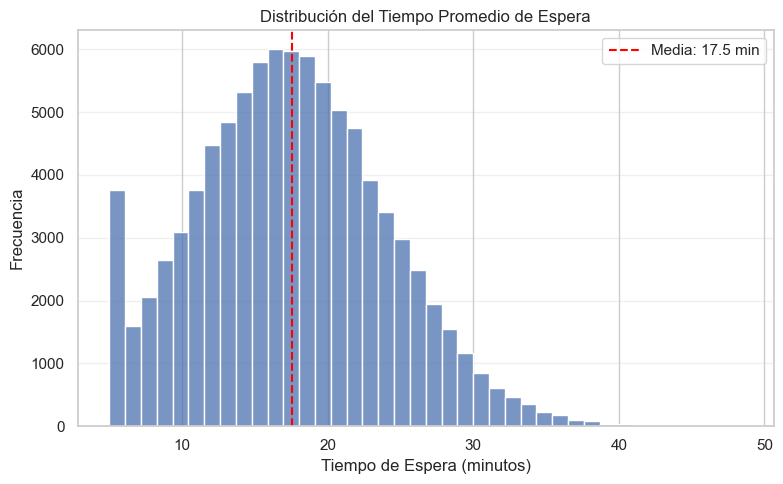

In [28]:
"""
Distribución del Tiempo Promedio de Espera
"""

plt.figure(figsize=(8,5))

sns.histplot(
    daily_metrics_df["average_wait_time"],
    bins=40
)

mean_wait = daily_metrics_df["average_wait_time"].mean()

plt.axvline(
    mean_wait,
    color="red",
    linestyle="--",
    label=f"Media: {mean_wait:.1f} min"
)

plt.title("Distribución del Tiempo Promedio de Espera")
plt.xlabel("Tiempo de Espera (minutos)")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("wait_time_distribution")

plt.tight_layout()

plt.show()

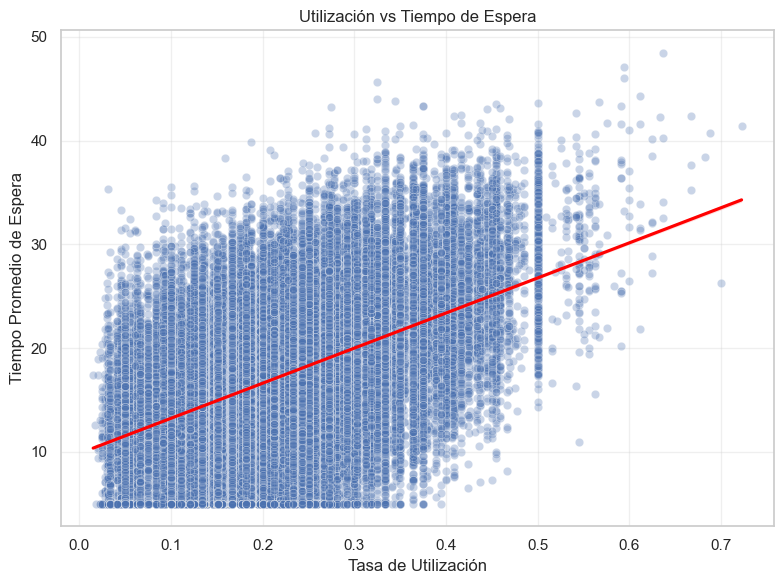

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=daily_metrics_df,
    x="vet_utilization_rate",
    y="average_wait_time",
    alpha=0.3
)

sns.regplot(
    data=daily_metrics_df,
    x="vet_utilization_rate",
    y="average_wait_time",
    scatter=False,
    color="red"
)

plt.title("Utilización vs Tiempo de Espera")

plt.xlabel("Tasa de Utilización")
plt.ylabel("Tiempo Promedio de Espera")

plt.grid(alpha=0.3)

save_plot("utilization_vs_wait_time")

plt.tight_layout()

plt.show()

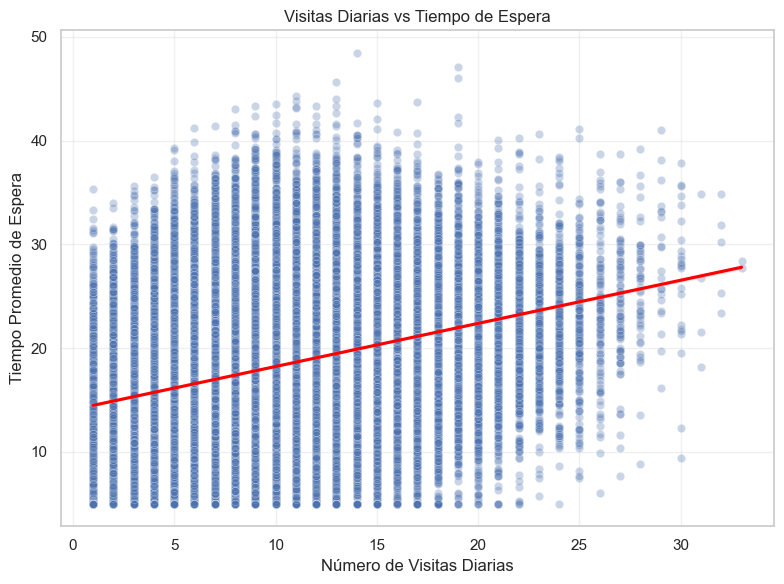

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=daily_metrics_df,
    x="number_of_daily_visits",
    y="average_wait_time",
    alpha=0.3
)

sns.regplot(
    data=daily_metrics_df,
    x="number_of_daily_visits",
    y="average_wait_time",
    scatter=False,
    color="red"
)

plt.title("Visitas Diarias vs Tiempo de Espera")

plt.xlabel("Número de Visitas Diarias")
plt.ylabel("Tiempo Promedio de Espera")

plt.grid(alpha=0.3)

save_plot("visits_vs_wait_time")

plt.tight_layout()

plt.show()

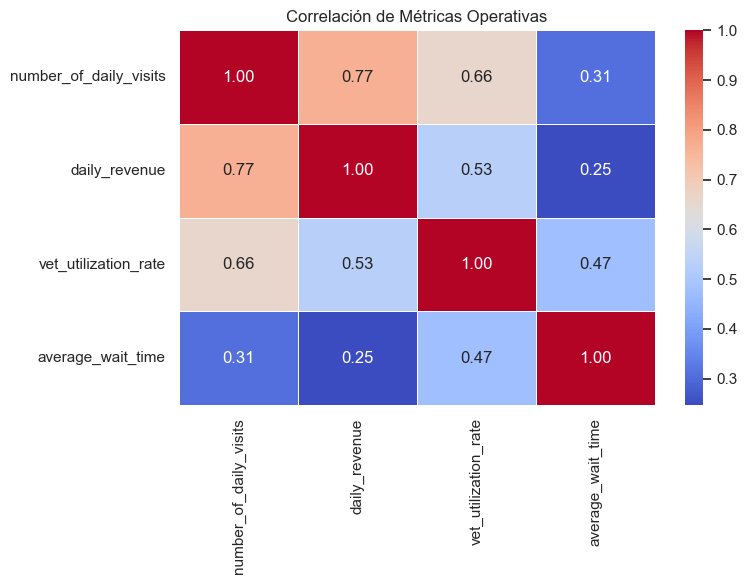

In [31]:
numeric_metrics = daily_metrics_df[
    [
        "number_of_daily_visits",
        "daily_revenue",
        "vet_utilization_rate",
        "average_wait_time"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_metrics.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlación de Métricas Operativas")

save_plot("operational_metrics_correlation")

plt.tight_layout()

plt.show()

### Insight

Las métricas operativas revelan una fuerte relación entre la utilización de las clínicas y los tiempos de espera.

A medida que las tasas de utilización aumentan, las clínicas experimentan tiempos de espera más largos, lo que indica una mayor presión operativa.

Esto resalta la importancia de equilibrar la capacidad de las clínicas con los niveles de demanda para mantener una experiencia eficiente y positiva para los clientes.

Estos insights pueden ayudar a orientar decisiones relacionadas con la asignación de personal, la programación de citas y la expansión de clínicas.

## Principales Insights del Análisis Exploratorio

El análisis exploratorio de la red de clínicas veterinarias Mexikans revela varios patrones operativos y de comportamiento importantes en toda la organización.

### Demanda Geográfica

La demanda veterinaria está más concentrada en las grandes áreas metropolitanas, donde una mayor densidad poblacional y mayores niveles de tenencia de mascotas generan una demanda más fuerte de servicios veterinarios.

### Mezcla de Servicios

Los servicios rutinarios como consultas y vacunaciones representan la mayoría de las visitas veterinarias en la red. Aunque estos servicios impulsan el volumen de pacientes, los procedimientos más complejos como cirugías y estudios de imagen generan ingresos significativamente mayores por visita.

### Comportamiento de los Clientes

El análisis del comportamiento de los clientes indica patrones recurrentes de atención veterinaria. La mayoría de las mascotas visitan las clínicas un número limitado de veces al año para chequeos de rutina, vacunaciones y tratamientos médicos ocasionales, lo que refleja un comportamiento realista de atención preventiva.

### Desempeño de las Clínicas

El desempeño de las clínicas varía a lo largo de la red. Algunas clínicas generan volúmenes de pacientes e ingresos significativamente más altos, mientras que otras operan por debajo de su capacidad potencial. Estas diferencias pueden estar influenciadas por el tamaño de la clínica, la ubicación y las condiciones de demanda local.

### Eficiencia Operativa

Las métricas operativas revelan que niveles más altos de utilización están asociados con tiempos de espera más largos. Esto resalta la importancia de equilibrar la demanda de pacientes con la capacidad de las clínicas para mantener operaciones eficientes y una experiencia positiva para los clientes.

### Próximos Pasos

Los insights generados en este análisis exploratorio guiarán la siguiente etapa del proyecto: **ingeniería de características**. En el siguiente notebook se crearán variables adicionales de tipo conductual, operativo y temporal para apoyar análisis avanzados, segmentación de clínicas y modelos de pronóstico de demanda.